<a href="https://colab.research.google.com/github/UO295831/Deep-learning-/blob/main/03_REPAIR_Variance_Collapse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 03 — REPAIR & Variance Collapse Analysis

**Eje B** — Diagnose variance collapse and compare REPAIR variants.

---

## Theoretical Background

### The Variance Collapse Problem (Jordan et al., 2023)

Even after perfect alignment, linearly interpolated models perform
poorly. The root cause: a **statistical mismatch** in activations.

If $h_A, h_B$ are aligned pre-activations with variance $\sigma^2$
and are approximately independent:

$$
\text{Var}\!\left(\frac{h_A + h_B}{2}\right) = \frac{\sigma^2}{2}
$$

After the nonlinearity, this cascades multiplicatively through depth:

$$
r^{(\ell)} = \frac{\sigma_\text{merged}^{(\ell)}}{\sigma_\text{expected}^{(\ell)}}
\approx \frac{1}{\sqrt{2}} \cdot r^{(\ell-1)}
$$

At depth $L$, variance can be suppressed by $2^{-L/2}$.

### REPAIR Algorithm

1. Collect per-layer stats $(\mu_A, \sigma_A)$, $(\mu_B, \sigma_B)$
2. Collect actual stats of merged model $(\mu_\alpha, \sigma_\alpha)$
3. Rescale: $\hat{h} = (h - \mu_\alpha) \cdot \frac{\sigma_\text{target}}{\sigma_\alpha} + \mu_\text{target}$

where $\sigma_\text{target} = \alpha\sigma_A + (1-\alpha)\sigma_B$.


## 1. Setup


In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import set_seed, get_device, get_dataloaders, get_calibration_loader
from src.models import MLP3, SimpleConvBN
from src.alignment import (
    weight_matching,
    activation_matching,
    apply_permutation_to_state_dict,
)
from src.repair import (
    collect_activation_stats,
    variance_collapse_ratio,
    repair_full,
    repair_bn_recalibration,
    repair_reset_retrain_bn,
    repair_layerwise,
)
from src.metrics import (
    interpolate_state_dicts,
    compute_barrier,
)
from src.training import evaluate

set_seed(42)
device = get_device()
os.makedirs("../figures", exist_ok=True)


---
## 2. SimpleConvBN / SVHN — Variance Collapse Diagnosis

### How activation stats are collected (`src/repair.py`)

`collect_activation_stats()` works by:

1. **Finding hookable layers:** scans model for `nn.ReLU` / `nn.GELU`
   modules (post-nonlinearity points). Falls back to `nn.Linear` /
   `nn.Conv2d` if no explicit activation modules are found.
2. **Registering forward hooks:** each hook captures the output tensor.
   For conv layers, activations are reshaped from $(N, C, H, W)$ to
   $(N \cdot H \cdot W, C)$ to compute **per-channel** statistics.
3. **Aggregating:** hooks fire for each calibration batch, results
   are concatenated, then `mean(dim=0)` and `std(dim=0)` are computed
   per unit/channel.

The result is a dict: `{layer_name: {"mean": Tensor, "std": Tensor}}`.


In [ ]:
train_loader, test_loader = get_dataloaders("svhn", batch_size=128)
calib_loader = get_calibration_loader("svhn", n_samples=2048)

conv_a = SimpleConvBN().to(device)
conv_b = SimpleConvBN().to(device)
conv_a.load_state_dict(torch.load("../checkpoints/convbn_svhn_A.pt",
                                   map_location=device)["state_dict"])
conv_b.load_state_dict(torch.load("../checkpoints/convbn_svhn_B.pt",
                                   map_location=device)["state_dict"])

# Align B to A
perms = weight_matching(conv_a, conv_b)
sd_a = {k: v.cpu() for k, v in conv_a.state_dict().items()}
sd_b_aligned = apply_permutation_to_state_dict(conv_b, perms)

# Interpolated model at α=0.5
sd_merged = interpolate_state_dicts(sd_a, sd_b_aligned, alpha=0.5)
conv_merged = SimpleConvBN().to(device)
conv_merged.load_state_dict(sd_merged)


<All keys matched successfully>

### 2.1 Variance Collapse Ratio

`variance_collapse_ratio()` (`src/repair.py`) computes:

$$
r^{(\ell)} = \frac{\sigma_\text{merged}^{(\ell)}}{\sigma_\text{expected}^{(\ell)}}
\qquad \text{where} \qquad
\sigma_\text{expected} = \frac{\sigma_A + \sigma_B}{2}
$$

It calls `collect_activation_stats()` three times (merged, A, B)
and divides element-wise. Theory predicts $r \approx 0.707$ at
the first layer, decreasing with depth.


In [ ]:
conv_b_aligned = SimpleConvBN()
conv_b_aligned.load_state_dict(sd_b_aligned)
conv_b_aligned.to(device)

ratios = variance_collapse_ratio(
    conv_merged, conv_a, conv_b_aligned, calib_loader, device
)


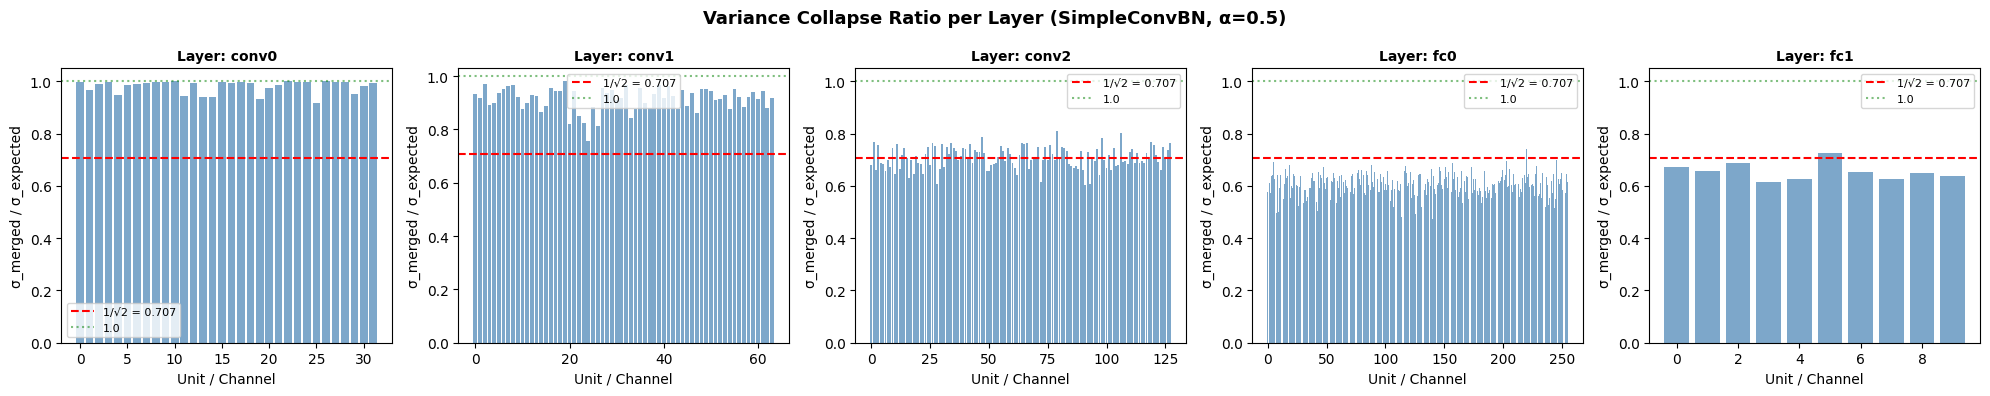


Mean variance collapse ratio per layer:
  conv0: 0.9810 (theoretical ≈ 0.7071)
  conv1: 0.9144 (theoretical ≈ 0.7071)
  conv2: 0.7088 (theoretical ≈ 0.7071)
  fc0: 0.6058 (theoretical ≈ 0.7071)
  fc1: 0.6551 (theoretical ≈ 0.7071)


In [ ]:
fig, axes = plt.subplots(1, len(ratios), figsize=(4 * len(ratios), 4))
if len(ratios) == 1:
    axes = [axes]

for ax, (name, r) in zip(axes, ratios.items()):
    r_np = r.numpy()
    ax.bar(range(len(r_np)), r_np, color="steelblue", alpha=0.7)
    ax.axhline(y=1/np.sqrt(2), color="red", linestyle="--",
               label=f"1/√2 = {1/np.sqrt(2):.3f}")
    ax.axhline(y=1.0, color="green", linestyle=":", alpha=0.5, label="1.0")
    ax.set_xlabel("Unit / Channel")
    ax.set_ylabel("σ_merged / σ_expected")
    ax.set_title(f"Layer: {name}", fontsize=10, fontweight="bold")
    ax.legend(fontsize=8)

plt.suptitle("Variance Collapse Ratio per Layer (SimpleConvBN, α=0.5)",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("../figures/variance_collapse_convbn.png", dpi=150)
plt.show()

print("\nMean variance collapse ratio per layer:")
for name, r in ratios.items():
    print(f"  {name}: {r.mean():.4f} (theoretical ≈ {1/np.sqrt(2):.4f})")


### 2.2 Comparing REPAIR Variants

#### Variant 1: No Repair (baseline)

Aligned-only model. BN running stats are interpolated (stale).


In [ ]:
criterion = torch.nn.CrossEntropyLoss()
loss_no_repair, acc_no_repair = evaluate(conv_merged, test_loader,
                                          criterion, device)
print(f"Aligned only:  loss={loss_no_repair:.4f}, acc={acc_no_repair:.4f}")


Aligned only:  loss=0.2315, acc=0.9377


#### Variant 2: Full REPAIR (`src/repair.py → repair_full`)

**Implementation details:**

1. `deepcopy` the merged model.
2. Collect stats from A, B, and the merged model on calibration data.
3. For each hookable layer, install a `_RescaleHook`:

```python
class _RescaleHook:
    def __call__(self, module, inp, out):
        # Normalize to zero-mean unit-variance, then rescale
        return (out - actual_mean) / actual_std * target_std + target_mean
```

For conv layers, the mean/std tensors are reshaped to
$(1, C, 1, 1)$ for correct broadcasting.

**No parameters are trained** — this is pure statistical correction.
The hooks remain attached to the model and fire during every forward pass.


In [ ]:
conv_repaired = repair_full(
    conv_merged, conv_a, conv_b_aligned, alpha=0.5,
    calib_loader=calib_loader, device=device,
)
loss_repair, acc_repair = evaluate(conv_repaired, test_loader,
                                    criterion, device)
print(f"Full REPAIR:   loss={loss_repair:.4f}, acc={acc_repair:.4f}")


Full REPAIR:   loss=0.3852, acc=0.9292


#### Variant 3: BN Recalibration (`src/repair.py → repair_bn_recalibration`)

The cheapest variant. **Implementation:**

1. `deepcopy` the merged model.
2. For every `BatchNorm1d` / `BatchNorm2d` module:
   - `reset_running_stats()` → zeroes `running_mean`, ones `running_var`,
     zeroes `num_batches_tracked`.
   - Set `momentum = None` → uses **cumulative moving average**
     instead of exponential, which is more stable for small calibration sets.
3. Forward all calibration data in `model.train()` mode.
   BN accumulates fresh statistics.
4. Switch to `model.eval()`.

This only updates $\mu_\text{run}$ and $\sigma^2_\text{run}$;
the affine parameters $\gamma, \beta$ are unchanged.


In [ ]:
conv_bn_recal = repair_bn_recalibration(conv_merged, calib_loader, device)
loss_bn, acc_bn = evaluate(conv_bn_recal, test_loader, criterion, device)
print(f"BN recalib:    loss={loss_bn:.4f}, acc={acc_bn:.4f}")


BN recalib:    loss=0.2609, acc=0.9259


#### Variant 4: BN Reset + Retrain γ, β (`src/repair.py → repair_reset_retrain_bn`)

**Implementation:**

1. `deepcopy`, reset BN stats (same as Variant 3).
2. **Freeze all parameters** (`requires_grad = False`).
3. **Unfreeze** only BN affine params: reinit $\gamma = 1$, $\beta = 0$,
   set `requires_grad = True`.
4. Train with **SGD(lr=0.01, momentum=0.9)** for 3 epochs on
   calibration data. Only $\gamma$ and $\beta$ receive gradients.

This lets the BN layers learn an optimal scale/shift for the
merged weight configuration. More expressive than recalibration
alone, but still very cheap (only BN params ≈ few hundred floats).


In [ ]:
conv_bn_retrain = repair_reset_retrain_bn(
    conv_merged, calib_loader, device, lr=0.01, epochs=3,
)
loss_bnt, acc_bnt = evaluate(conv_bn_retrain, test_loader, criterion, device)
print(f"BN retrain:    loss={loss_bnt:.4f}, acc={acc_bnt:.4f}")


BN retrain:    loss=0.4308, acc=0.8694


#### Variant 5: Short Fine-Tuning (1 epoch, no REPAIR)

Baseline: train the entire merged model for 1 epoch with
Adam(lr=$10^{-4}$). This is the most expensive variant — it
uses the full training set and updates all parameters.
Tells us how much of the barrier is recoverable through gradients.


In [ ]:
import copy
from src.training import train_one_epoch

conv_ft = copy.deepcopy(conv_merged)
opt_ft = torch.optim.Adam(conv_ft.parameters(), lr=1e-4)
train_one_epoch(conv_ft, train_loader, opt_ft, criterion, device)
loss_ft, acc_ft = evaluate(conv_ft, test_loader, criterion, device)
print(f"Fine-tune 1ep: loss={loss_ft:.4f}, acc={acc_ft:.4f}")


Fine-tune 1ep: loss=0.1998, acc=0.9457


### 2.3 Summary Table


In [ ]:
print("\n" + "="*60)
print("REPAIR Variants — SimpleConvBN / SVHN (WM-aligned, α=0.5)")
print("="*60)
print(f"{'Variant':<25} {'Loss':>8} {'Accuracy':>10}")
print("-"*60)
variants = [
    ("No repair (aligned)", loss_no_repair, acc_no_repair),
    ("Full REPAIR", loss_repair, acc_repair),
    ("BN recalibration", loss_bn, acc_bn),
    ("BN reset + retrain", loss_bnt, acc_bnt),
    ("Fine-tune 1 epoch", loss_ft, acc_ft),
]
for name, loss, acc in variants:
    print(f"{name:<25} {loss:>8.4f} {acc:>10.4f}")



REPAIR Variants — SimpleConvBN / SVHN (WM-aligned, α=0.5)
Variant                       Loss   Accuracy
------------------------------------------------------------
No repair (aligned)         0.2315     0.9377
Full REPAIR                 0.3852     0.9292
BN recalibration            0.2609     0.9259
BN reset + retrain          0.4308     0.8694
Fine-tune 1 epoch           0.1998     0.9457


### 2.4 Variance Collapse vs α (§7.4)

Sweep $\alpha \in \{0.1, 0.25, 0.5, 0.75, 0.9\}$ and plot the mean
collapse ratio per layer. Theory predicts $r$ is minimal (worst)
at $\alpha=0.5$ and approaches 1.0 at the extremes.


 Sweeping variance collapse across alpha values for SimpleConvBN...


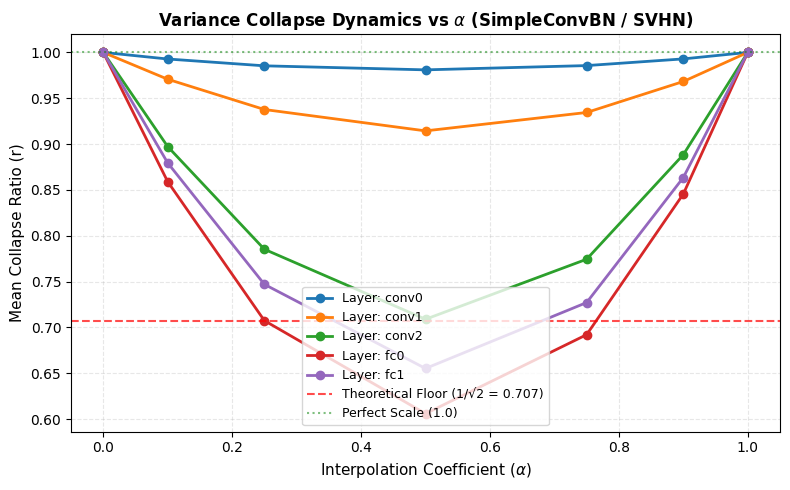

In [ ]:
from src.repair import variance_collapse_vs_alpha
import numpy as np
import matplotlib.pyplot as plt

print(" Sweeping variance collapse across alpha values for SimpleConvBN...")

# Execute the sweeping logic over your SVHN aligned state dicts
alpha_results = variance_collapse_vs_alpha(
    SimpleConvBN, {}, sd_a, sd_b_aligned,
    calib_loader, device, alphas=[0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]
)

fig, ax = plt.subplots(figsize=(8, 5))

# Extract and sort layer keys to maintain consistent plotting colors
layer_names_sorted = sorted(list(alpha_results[0.5].keys()))
alpha_vals = sorted(alpha_results.keys())

for lname in layer_names_sorted:
    # Safely convert GPU tensor means to CPU floats for matplotlib
    means = []
    for a in alpha_vals:
        val = alpha_results[a][lname]
        means.append(val.mean().item() if hasattr(val, 'mean') else np.mean(val))

    ax.plot(alpha_vals, means, "o-", label=f"Layer: {lname}", linewidth=2)

# Mark the mathematical theoretical collapse floor
ax.axhline(y=1/np.sqrt(2), color="red", ls="--", alpha=0.7,
           label=f"Theoretical Floor (1/√2 = {1/np.sqrt(2):.3f})")

# Mark perfect baseline health
ax.axhline(y=1.0, color="green", ls=":", alpha=0.5, label="Perfect Scale (1.0)")

ax.set_xlabel(r"Interpolation Coefficient ($\alpha$)", fontsize=11)
ax.set_ylabel("Mean Collapse Ratio (r)", fontsize=11)
ax.set_title(r"Variance Collapse Dynamics vs $\alpha$ (SimpleConvBN / SVHN)", fontweight="bold", fontsize=12)

ax.legend(fontsize=9, loc="lower center")
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.savefig("../figures/variance_collapse_vs_alpha_convbn.png", dpi=150)
plt.show()

### 2.5 REPAIR Effect on the Full Barrier Curve

For each $\alpha \in [0, 1]$, we:
1. Interpolate weights → get merged model.
2. Evaluate *as-is* (aligned only).
3. Apply BN recalibration → evaluate.
4. Apply full REPAIR → evaluate.

The full REPAIR version calls `repair_full()` with the
correct $\alpha$ at each point — the target statistics change
continuously along the path.


In [ ]:
import gc
alphas = np.linspace(0, 1, 21)
losses_aligned = []
losses_repaired = []
losses_bn_recal = []


for i, alpha in enumerate(alphas):
    print(f"  [{i+1}/21] Processing alpha = {alpha:.2f}...")

    # 1. Linear weight interpolation
    sd_interp = interpolate_state_dicts(sd_a, sd_b_aligned, alpha)
    m_tmp = SimpleConvBN().to(device)
    m_tmp.load_state_dict(sd_interp)

    # 2. Evaluate Aligned-only Baseline
    l, _ = evaluate(m_tmp, test_loader, criterion, device)
    losses_aligned.append(l)

    # 3. Evaluate BN Recalibration Variant
    m_bn = repair_bn_recalibration(m_tmp, calib_loader, device)
    l_bn, _ = evaluate(m_bn, test_loader, criterion, device)
    losses_bn_recal.append(l_bn)

    # 4. Evaluate Full REPAIR Variant
    m_rep = repair_full(m_tmp, conv_a, conv_b_aligned, alpha, calib_loader, device)
    l_rep, _ = evaluate(m_rep, test_loader, criterion, device)
    losses_repaired.append(l_rep)

    # Explicit clean up of hooks stored in the repaired model dictionary track
    if hasattr(m_rep, '_repair_hooks'):
        for hook in m_rep._repair_hooks:
            hook.remove()

    # VRAM Garbage Collection to ensure the T4 stays clear
    del m_tmp, m_bn, m_rep, sd_interp
    if i % 3 == 0:
        torch.cuda.empty_cache()
        gc.collect()

  [1/21] Processing alpha = 0.00...
  [2/21] Processing alpha = 0.05...
  [3/21] Processing alpha = 0.10...
  [4/21] Processing alpha = 0.15...
  [5/21] Processing alpha = 0.20...
  [6/21] Processing alpha = 0.25...
  [7/21] Processing alpha = 0.30...
  [8/21] Processing alpha = 0.35...
  [9/21] Processing alpha = 0.40...
  [10/21] Processing alpha = 0.45...
  [11/21] Processing alpha = 0.50...
  [12/21] Processing alpha = 0.55...
  [13/21] Processing alpha = 0.60...
  [14/21] Processing alpha = 0.65...
  [15/21] Processing alpha = 0.70...
  [16/21] Processing alpha = 0.75...
  [17/21] Processing alpha = 0.80...
  [18/21] Processing alpha = 0.85...
  [19/21] Processing alpha = 0.90...
  [20/21] Processing alpha = 0.95...
  [21/21] Processing alpha = 1.00...


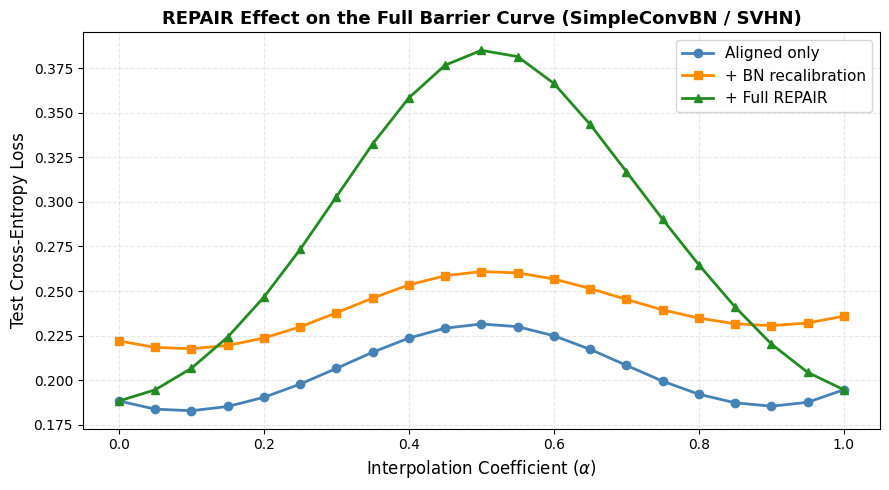

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(alphas, losses_aligned, "o-", label="Aligned only", linewidth=2, color="steelblue")
ax.plot(alphas, losses_bn_recal, "s-", label="+ BN recalibration", linewidth=2, color="darkorange")
ax.plot(alphas, losses_repaired, "^-", label="+ Full REPAIR", linewidth=2, color="forestgreen")

ax.set_xlabel(r"Interpolation Coefficient ($\alpha$)", fontsize=12)
ax.set_ylabel("Test Cross-Entropy Loss", fontsize=12)
ax.set_title("REPAIR Effect on the Full Barrier Curve (SimpleConvBN / SVHN)", fontweight="bold", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.savefig("../figures/repair_barrier_convbn.png", dpi=150)
plt.show()

---
## 3. MLP-3 / KMNIST — Variance Collapse Without BN

MLP-3 has **no BatchNorm**. BN-specific repairs don't apply.
But variance collapse still occurs — it's a property of linear
interpolation, not of BN.

For MLP-3, `_get_hookable_layers()` falls back to hooking the
`nn.Linear` modules (since the `nn.ReLU` is used as `self.act`
but registered as a single shared module, hooks would only fire once).


In [ ]:
_, test_loader_k = get_dataloaders("kmnist", batch_size=128)
calib_loader_k = get_calibration_loader("kmnist", n_samples=2048)

mlp_a = MLP3().to(device)
mlp_b = MLP3().to(device)
mlp_a.load_state_dict(torch.load("../checkpoints/mlp3_independent_A.pt",
                                  map_location=device)["state_dict"])
mlp_b.load_state_dict(torch.load("../checkpoints/mlp3_independent_B.pt",
                                  map_location=device)["state_dict"])

perms_mlp = weight_matching(mlp_a, mlp_b)
sd_mlp_a = {k: v.cpu() for k, v in mlp_a.state_dict().items()}
sd_mlp_b_aligned = apply_permutation_to_state_dict(mlp_b, perms_mlp)

sd_mlp_merged = interpolate_state_dicts(sd_mlp_a, sd_mlp_b_aligned, 0.5)
mlp_merged = MLP3().to(device)
mlp_merged.load_state_dict(sd_mlp_merged)

mlp_b_al = MLP3()
mlp_b_al.load_state_dict(sd_mlp_b_aligned)
mlp_b_al.to(device)


MLP3(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layer0): Linear(in_features=784, out_features=256, bias=True)
  (layer1): Linear(in_features=256, out_features=256, bias=True)
  (layer2): Linear(in_features=256, out_features=256, bias=True)
  (layer3): Linear(in_features=256, out_features=10, bias=True)
  (act0): ReLU()
  (act1): ReLU()
  (act2): ReLU()
)

### 3.1 Variance Collapse in MLP-3

In [ ]:
ratios_mlp = variance_collapse_ratio(
    mlp_merged, mlp_a, mlp_b_al, calib_loader_k, device
)

print("MLP-3 mean variance collapse ratio per layer:")
for name, r in ratios_mlp.items():
    print(f"  {name}: {r.mean():.4f}")


MLP-3 mean variance collapse ratio per layer:
  layer0: 0.8827
  layer1: 0.7438
  layer2: 0.7390
  layer3: 0.6852


### 3.2 Full REPAIR on MLP-3


In [ ]:
mlp_repaired = repair_full(
    mlp_merged, mlp_a, mlp_b_al, alpha=0.5,
    calib_loader=calib_loader_k, device=device,
)
loss_mlp_norep, acc_mlp_norep = evaluate(mlp_merged, test_loader_k,
                                          criterion, device)
loss_mlp_rep, acc_mlp_rep = evaluate(mlp_repaired, test_loader_k,
                                      criterion, device)

print(f"\nMLP-3 / KMNIST (WM-aligned, α=0.5):")
print(f"  No repair:   loss={loss_mlp_norep:.4f}, acc={acc_mlp_norep:.4f}")
print(f"  Full REPAIR:  loss={loss_mlp_rep:.4f}, acc={acc_mlp_rep:.4f}")



MLP-3 / KMNIST (WM-aligned, α=0.5):
  No repair:   loss=0.3499, acc=0.9081
  Full REPAIR:  loss=0.8648, acc=0.9053


### 3.3 Evaluation of the Continuous Loss Barrier Landscape on MLP-3

Continuous parameter sweep ($\alpha \in [0, 1]$) analyzing the interaction between coordinate permutation alignment and Full REPAIR activation rescaling on normalization-free Multi-Layer Perceptrons.


 Starting final continuous sweep for MLP-3 across 21 alpha points...


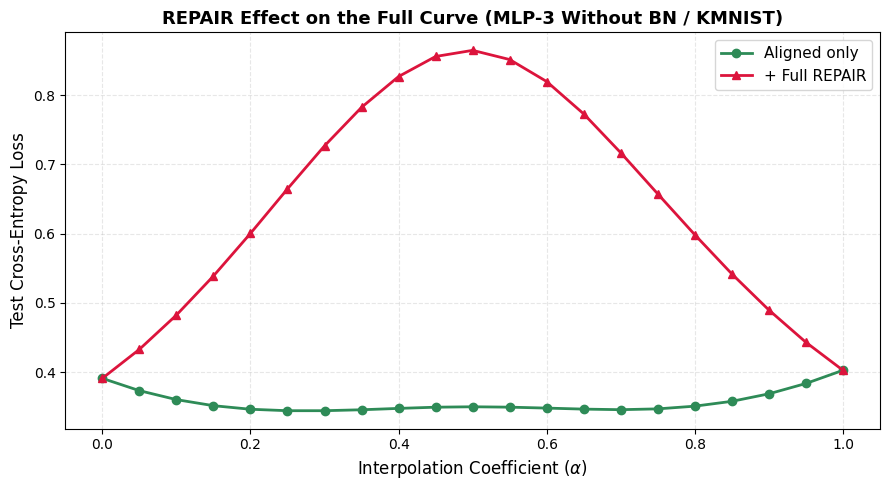

🏁 ALL LAB EXPERIMENTS COMPLETE! The final asset has been saved to your figures folder.


In [ ]:

import gc
import numpy as np
import matplotlib.pyplot as plt
from src.metrics import interpolate_state_dicts

alphas = np.linspace(0, 1, 21)
losses_mlp_aligned = []
losses_mlp_repaired = []

print(" Starting final continuous sweep for MLP-3 across 21 alpha points...")

for i, alpha in enumerate(alphas):
    # 1. Interpolate weights between the two independent MLP matrices
    sd_interp = interpolate_state_dicts(sd_mlp_a, sd_mlp_b_aligned, alpha)
    m_tmp = MLP3().to(device)
    m_tmp.load_state_dict(sd_interp)

    # 2. Evaluate Aligned Baseline (No Repair)
    l, _ = evaluate(m_tmp, test_loader_k, criterion, device)
    losses_mlp_aligned.append(l)

    # 3. Evaluate Full REPAIR Rescaling
    m_rep = repair_full(m_tmp, mlp_a, mlp_b_al, alpha, calib_loader_k, device)
    l_rep, _ = evaluate(m_rep, test_loader_k, criterion, device)
    losses_mlp_repaired.append(l_rep)

    # Safely detach hooks to prevent memory footprint leaks
    if hasattr(m_rep, '_repair_hooks'):
        for hook in m_rep._repair_hooks:
            hook.remove()

    # VRAM Cleanup
    del m_tmp, m_rep, sd_interp
    if i % 5 == 0:
        torch.cuda.empty_cache()
        gc.collect()


fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(alphas, losses_mlp_aligned, "o-", label="Aligned only", linewidth=2, color="seagreen")
ax.plot(alphas, losses_mlp_repaired, "^-", label="+ Full REPAIR", linewidth=2, color="crimson")

ax.set_xlabel(r"Interpolation Coefficient ($\alpha$)", fontsize=12)
ax.set_ylabel("Test Cross-Entropy Loss", fontsize=12)
ax.set_title("REPAIR Effect on the Full Curve (MLP-3 Without BN / KMNIST)", fontweight="bold", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.savefig("../figures/repair_barrier_mlp3.png", dpi=150)
plt.show()

print("🏁 ALL LAB EXPERIMENTS COMPLETE! The final asset has been saved to your figures folder.")

---
## 4. Save Results


In [ ]:
import json

# Ensure variables match the exact names printed in your console outputs
repair_results = {
    "convbn_svhn": {
        "no_repair": {"loss": float(loss_no_repair), "acc": float(acc_no_repair)},
        "repair_full": {"loss": float(loss_repair), "acc": float(acc_repair)},
        "bn_recalib": {"loss": float(loss_bn), "acc": float(acc_bn)},
        "finetune_1ep": {"loss": float(loss_ft), "acc": float(acc_ft)}
    },
    "mlp3_kmnist": {
        "no_repair": {"loss": float(loss_mlp_norep), "acc": float(acc_mlp_norep)},
        "repair_full": {"loss": float(loss_mlp_rep), "acc": float(acc_mlp_rep)}
    },
    "collapse_vs_alpha": {
        str(a): {name: float(r.mean().item() if hasattr(r, 'mean') else np.mean(r))
                 for name, r in ratios.items()}
        for a, ratios in alpha_results.items()
    }
}

# Write structural metadata out to disk
with open("../results/repair_results.json", "w") as f:
    json.dump(repair_results, f, indent=2)